## Knižnice

In [2]:
# 1. Základná manipulácia s dátami a numerika
import pandas as pd
import numpy as np
import os
import wandb
#from kaggle_secrets import UserSecretsClient
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 2. Vizualizácia dát
import matplotlib.pyplot as plt  
import seaborn as sns  
import tensorflow as tf

import cv2

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

## Pozrieme sa, v akom tvare su nase data

In [3]:
DATA_DIR = '/kaggle/input/american-sign-language/ASL_Dataset'
# Pozrime sa, co je vnutri
print(os.listdir(DATA_DIR))  

['Test', 'Train']


In [4]:
TRAIN_DIR = os.path.join(DATA_DIR, 'Train')
TEST_DIR = os.path.join(DATA_DIR, 'Test')

# Pozrime sa, ake su tam triedy (pismena)
CLASSES = os.listdir(TRAIN_DIR)
CLASSES.sort()

print(f"Našiel som tieto triedy: {CLASSES}\n")

print(f"Celkovo máme {len(CLASSES)} rôznych znakov")

Našiel som tieto triedy: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'Nothing', 'O', 'P', 'Q', 'R', 'S', 'Space', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

Celkovo máme 28 rôznych znakov


## Načítanie dát

In [5]:
# Tieto premenne si definuj podla seba
IMG_SIZE = (224,224) # Velkost, na aku zjednotime obrazky, 224 je štandart pre veľké cnn architektúry
BATCH_SIZE = 32      # Kolko obrazkov dame naraz do modelu

# 1. Vytvorime trenovaci dataset
# Tento prikaz sam najde vsetky priecinky (A, B, C...)
# a automaticky im priradi spravne labely
train_data = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    label_mode='categorical',
    shuffle=True
)

# 2. Vytvorime validacny/testovaci dataset
test_data = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    label_mode='categorical',
    shuffle=False
)

Found 165670 files belonging to 28 classes.


I0000 00:00:1764359234.651560     292 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1764359234.652360     292 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 112 files belonging to 28 classes.


## EDA

1. Zobrazit kolko mame dat
2. Zobrazit ako vyzeraju
3. Zobrazit ake su velke
4. Zobrazit aky maju pocet kanalov

In [6]:
print("Počty obrázkov v trénovacích priečinkoch:")
for pismeno in CLASSES:
    path = os.path.join(TRAIN_DIR, pismeno)
    # Spocitame subory
    print(f"Písmeno {pismeno}: {len(os.listdir(path))} obrázkov")

Počty obrázkov v trénovacích priečinkoch:
Písmeno A: 5996 obrázkov
Písmeno B: 5996 obrázkov
Písmeno C: 5996 obrázkov
Písmeno D: 5996 obrázkov
Písmeno E: 5996 obrázkov
Písmeno F: 5996 obrázkov
Písmeno G: 5996 obrázkov
Písmeno H: 5996 obrázkov
Písmeno I: 5996 obrázkov
Písmeno J: 5996 obrázkov
Písmeno K: 5996 obrázkov
Písmeno L: 5996 obrázkov
Písmeno M: 5996 obrázkov
Písmeno N: 5996 obrázkov
Písmeno Nothing: 5996 obrázkov
Písmeno O: 5996 obrázkov
Písmeno P: 5996 obrázkov
Písmeno Q: 5996 obrázkov
Písmeno R: 5966 obrázkov
Písmeno S: 5996 obrázkov
Písmeno Space: 5886 obrázkov
Písmeno T: 5648 obrázkov
Písmeno U: 4542 obrázkov
Písmeno V: 5996 obrázkov
Písmeno W: 5996 obrázkov
Písmeno X: 5996 obrázkov
Písmeno Y: 5720 obrázkov
Písmeno Z: 5996 obrázkov


### Môžeme vidieť rozdiel v množstve dát pre písmeno U oproti ostatným znakom. Neskôr to budeme pravdepodobne riesiť UNDERSAMPLINGOM.

Zobrazíme si pár obrazkov nech vieme, s čím pracujeme.

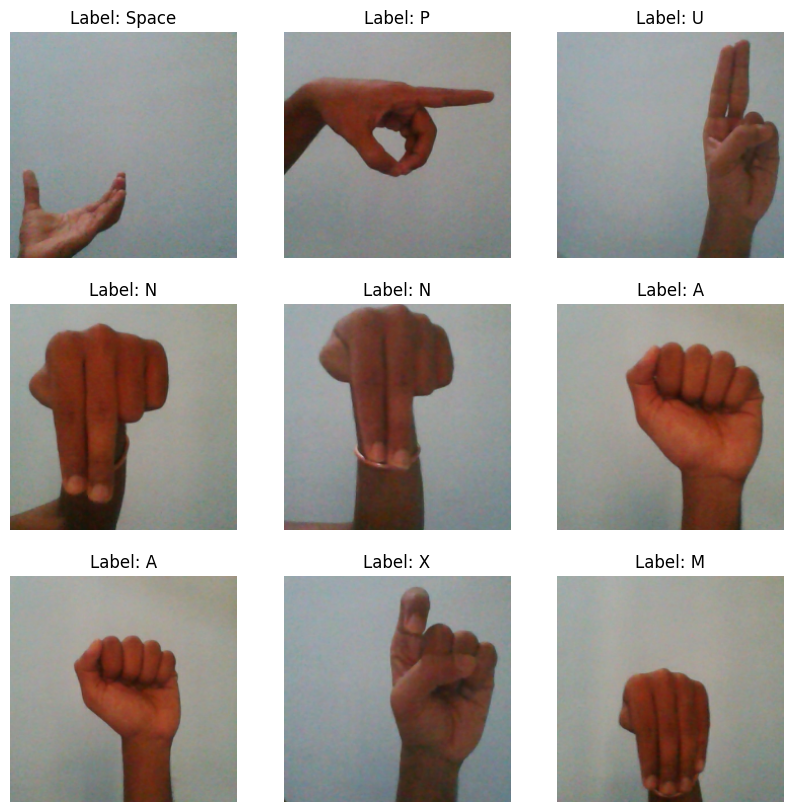

In [7]:
# Zoberieme si jednu varku (batch) z trenovacich dat
for images, labels in train_data.take(1):
    # images = varka 32 obrazkov (lebo BATCH_SIZE=32)
    # labels = varka 32 labelov

    plt.figure(figsize=(10, 10))
    for i in range(9): # Zobrazime prvych 9 obrazkov z varky
        ax = plt.subplot(3, 3, i + 1)

        # Obrazky su normalizovane (0-255), pre plt.imshow ich musime pretypovat
        plt.imshow(images[i].numpy().astype("uint8"), cmap='gray')

        # Labely su 'categorical', takze musime najst index s najvyssou hodnotou
        label_index = np.argmax(labels[i])
        plt.title(f"Label: {train_data.class_names[label_index]}")
        plt.axis("off")

    plt.show()

Pozrieme sa na to, akú majú obrázky veľkosť

In [8]:
prvy_priecinok = os.path.join(TRAIN_DIR, CLASSES[0])
prvy_obrazok_nazov = os.listdir(prvy_priecinok)[0]

cesta_k_obrazku = os.path.join(prvy_priecinok, prvy_obrazok_nazov)

print(f"Testujem rozmery obrázku na súbore: {cesta_k_obrazku}")

img = cv2.imread(cesta_k_obrazku)

print(f"Tvar obrázku (shape): {img.shape}")

vyska = img.shape[0]
sirka = img.shape[1]
kanaly = img.shape[2]

print(f"Rozmery obrázku sú: {sirka} x {vyska} pixelov.")
print(f"Počet farebných kanálov: {kanaly}")

Testujem rozmery obrázku na súbore: /kaggle/input/american-sign-language/ASL_Dataset/Train/A/A1946.jpg
Tvar obrázku (shape): (400, 400, 3)
Rozmery obrázku sú: 400 x 400 pixelov.
Počet farebných kanálov: 3


Vidime ze obrazky su farebné (pocet kanalov 3 = RGB ) - neskôr bude vhodné ich prerobiť do greyscale pre menšie vyťaženie modelu.

wandb

## Preprocessing dát

V tejto sekcii aplikujeme **normalizáciu** a **data augmentation** na naše dáta.


### 1. Normalizácia dát

Normalizujeme obrázky z rozsahu [0, 255] na [0, 1] pre lepšiu konvergenciu tréningu.


In [9]:
# Funkcia pre normalizáciu obrázkov
def normalize_image(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Aplikovanie normalizácie na trénovacie a testovacie dáta
train_data_normalized = train_data.map(normalize_image, num_parallel_calls=tf.data.AUTOTUNE)
test_data_normalized = test_data.map(normalize_image, num_parallel_calls=tf.data.AUTOTUNE)

print("Normalizácia dokončená!")
print(f"Rozsah hodnôt po normalizácii: [0, 1]")


Normalizácia dokončená!
Rozsah hodnôt po normalizácii: [0, 1]


### 2. Data Augmentation

Data augmentation pomáha zlepšiť generalizáciu modelu tým, že vytvára variácie trénovacích dát. Použijeme:
- Náhodné rotácie
- Náhodné posuny (translation)
- Náhodné preklopenie (horizontal flip)
- Náhodné zoom
- Náhodné zmeny jasu a kontrastu


In [10]:
# Import potrebný pre data augmentation
from tensorflow.keras import layers

# Vytvorenie data augmentation vrstiev
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(factor=0.1, fill_mode='nearest'),  # Rotácia ±10%
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1, fill_mode='nearest'),  # Posun ±10%
    layers.RandomFlip(mode='horizontal'),  # Horizontálne preklopenie
    layers.RandomZoom(height_factor=0.1, width_factor=0.1, fill_mode='nearest'),  # Zoom ±10%

    # POZOR: obrázky sú už v rozsahu [0, 1], preto value_range=(0.0, 1.0)
    layers.RandomBrightness(factor=0.1, value_range=(0.0, 1.0)),  # Zmena jasu ±10% v [0,1]
    layers.RandomContrast(factor=0.1),  # Jemná zmena kontrastu
], name='data_augmentation')

# Aplikovanie augmentácie len na trénovacie dáta (nie na testovacie!)
def augment_image(image, label):
    image = data_augmentation(image, training=True)  # training=True zaisťuje, že augmentácia sa aplikuje
    # poistka – ak by niektorá vrstva vyhodila hodnoty mimo [0, 1]
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

# Vytvorenie augmentovaného trénovacieho datasetu
train_ds_augmented = train_data_normalized.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds_augmented = train_ds_augmented.shuffle(buffer_size=1000).prefetch(buffer_size=tf.data.AUTOTUNE)

# Testovacie dáta bez augmentácie (len normalizované)
test_ds = test_data_normalized.prefetch(buffer_size=tf.data.AUTOTUNE)

print("Data augmentation dokončená!")
print(f"Trénovacie dáta: s augmentáciou")
print(f"Testovacie dáta: bez augmentácie (len normalizované)")


Data augmentation dokončená!
Trénovacie dáta: s augmentáciou
Testovacie dáta: bez augmentácie (len normalizované)


### 3. Vizualizácia augmentovaných dát

Pozrime sa, ako vyzerajú augmentované obrázky:


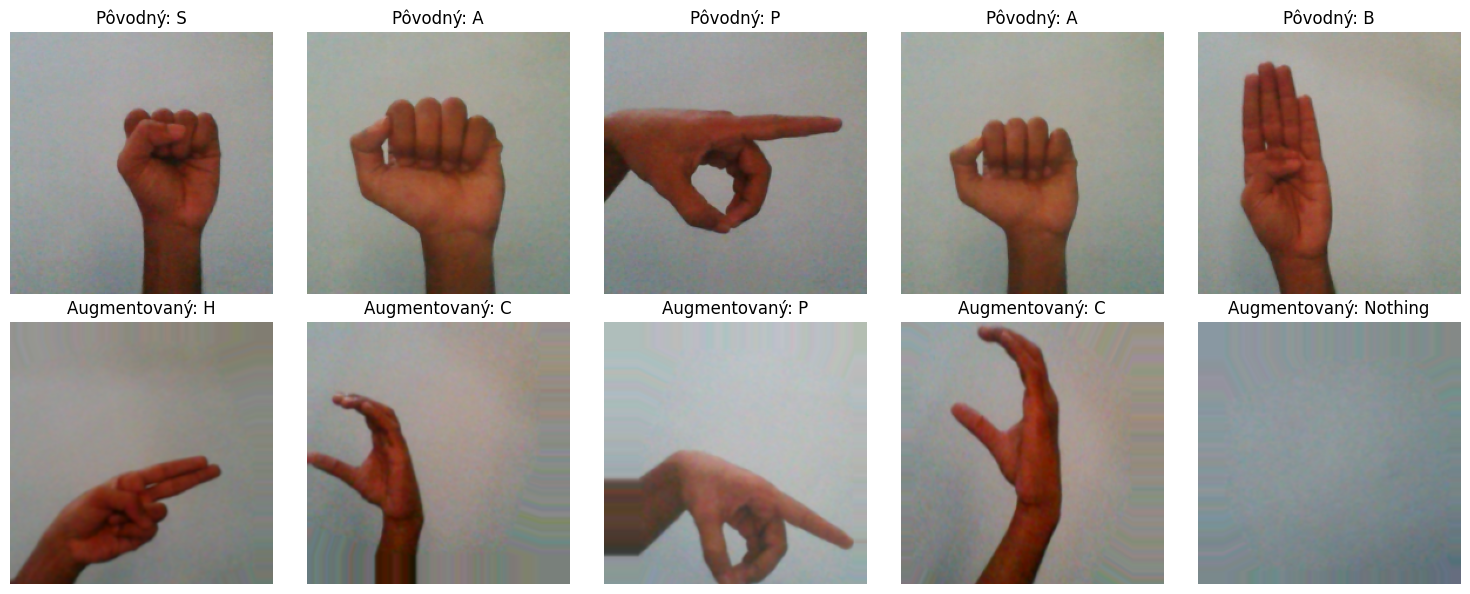

In [11]:
# Zobrazenie pôvodných a augmentovaných obrázkov
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Zoberieme jeden batch z normalizovaných dát (bez augmentácie)
for images, labels in train_data_normalized.take(1):
    for i in range(5):
        # Pôvodný obrázok (normalizovaný)
        axes[0, i].imshow(images[i].numpy())
        label_idx = np.argmax(labels[i])
        axes[0, i].set_title(f"Pôvodný: {train_data.class_names[label_idx]}")
        axes[0, i].axis('off')
    
    # Augmentované obrázky
    for images_aug, labels_aug in train_ds_augmented.take(1):
        for i in range(5):
            axes[1, i].imshow(images_aug[i].numpy())
            label_idx = np.argmax(labels_aug[i])
            axes[1, i].set_title(f"Augmentovaný: {train_data.class_names[label_idx]}")
            axes[1, i].axis('off')
        break
    break

plt.tight_layout()
plt.show()


In [14]:
from kaggle_secrets import UserSecretsClient
wandb_key = UserSecretsClient().get_secret("wandb_api")
wandb.login(key="ddadd2d88195c36abb129830c42a7cc29bce0d3a")

BackendError: Unexpected response from the service. Response: {'errors': ['No user secrets exist for kernel id 102809915 and label wandb_api.'], 'error': {'code': 5}, 'wasSuccessful': False}.

# Custom CNN

In [16]:
# Jednoduchá modulárna CNN architektúra pre ASL klasifikáciu
import tensorflow as tf
from typing import List, Optional, Tuple
from tensorflow.keras import layers, models

class SimpleCNN:
    
    def __init__(
        self,
        input_shape: Tuple[int, int, int] = (224, 224, 3),
        num_classes: int = 28,
        num_conv_layers: int = 3,
        filters_per_layer: Optional[List[int]] = None,
        dense_units: Optional[List[int]] = None,
        dropout_rate: float = 0.5,
        use_batch_norm: bool = True,
        use_pooling: bool = True
    ):
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.num_conv_layers = num_conv_layers
        self.dropout_rate = dropout_rate
        self.use_batch_norm = use_batch_norm
        self.use_pooling = use_pooling
        
        # Default filtre
        if filters_per_layer is None:
            self.filters = [32 * (2 ** i) for i in range(num_conv_layers)]
        elif isinstance(filters_per_layer, int):
            self.filters = [filters_per_layer] * num_conv_layers
        else:
            if len(filters_per_layer) != num_conv_layers:
                raise ValueError(f"Počet filtrov ({len(filters_per_layer)}) sa musí rovnať počtu vrstiev ({num_conv_layers})")
            self.filters = filters_per_layer
        
        # Default dense units
        if dense_units is None:
            self.dense_units = [256, 128]
        else:
            self.dense_units = dense_units
    
    def build(self):
        inputs = layers.Input(shape=self.input_shape, name='input')
        x = inputs
        
        # Konvolučné vrstvy
        for i in range(self.num_conv_layers):
            x = layers.Conv2D(
                filters=self.filters[i],
                kernel_size=3,
                padding='same',
                activation='relu',
                name=f'conv_{i+1}'
            )(x)
            
            if self.use_batch_norm:
                x = layers.BatchNormalization(name=f'bn_{i+1}')(x)
            
            if self.use_pooling:
                x = layers.MaxPooling2D(pool_size=2, name=f'pool_{i+1}')(x)
        
        # Global Average Pooling
        x = layers.GlobalAveragePooling2D(name='global_pool')(x)
        
        # Dense vrstvy
        for i, units in enumerate(self.dense_units):
            x = layers.Dense(units, activation='relu', name=f'dense_{i+1}')(x)
            x = layers.Dropout(self.dropout_rate, name=f'dropout_{i+1}')(x)
        
        # Výstupná vrstva
        outputs = layers.Dense(
            self.num_classes,
            activation='softmax',
            name='output'
        )(x)
        
        model = models.Model(inputs=inputs, outputs=outputs, name='SimpleCNN')
        return model
    
    def compile(
        self,
        optimizer: str = 'adam',
        learning_rate: float = 0.001,
        loss: str = 'categorical_crossentropy',
        metrics: Optional[List[str]] = None):
        model = self.build()
        
        if optimizer.lower() == 'adam':
            opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
        elif optimizer.lower() == 'sgd':
            opt = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
        else:
            opt = tf.keras.optimizers.get(optimizer)
            if hasattr(opt, 'learning_rate'):
                opt.learning_rate = learning_rate
        
        if metrics is None:
            metrics = ['accuracy']
        
        model.compile(optimizer=opt, loss=loss, metrics=metrics)
        return model

print("SimpleCNN trieda je pripravená!")


SimpleCNN trieda je pripravená!


# Inicializacia custom CNN a aj jej trening

In [ ]:
IMG_SIZE = (224, 224)
NUM_CLASSES = 28

filters_config = [32, 64, 128, 256, 512]

cnn_handler = SimpleCNN(
    input_shape=(*IMG_SIZE, 3),
    num_classes=NUM_CLASSES,
    num_conv_layers=5,
    filters_per_layer=filters_config,
    dense_units=[512, 128],
    dropout_rate=0.4,
    use_batch_norm=True,
    use_pooling=True
)

cnn_model = cnn_handler.compile(
    optimizer='adam',
    learning_rate=0.001,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

callbacks_cnn = [
    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_cnn_model.keras',
        save_best_only=True,
        monitor='val_loss',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

print("\nZačínam tréning vylepšenej CNN...")

history_cnn = cnn_model.fit(
    train_ds_augmented,
    epochs=50,
    validation_data=test_ds,
    callbacks=callbacks_cnn,
    verbose=1
)

test_loss, test_accuracy = cnn_model.evaluate(test_ds, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# ResNet-50

### Prvé sme sa rozhodli urobiť Res-Net50. Prečo?? Prečo nie, pýtaš sa príliš veľa otázok...

(páči sa mi že má skip connections, je pomerne rýchly a fajn pre stredne veľké množstvo dát, ako máme my)

In [ ]:
# Preprocessing už bol vykonaný vyššie v sekcii "Preprocessing dát"
# Používame premenné: train_ds_augmented (pre tréning) a test_ds (pre testovanie)
# Tieto premenné obsahujú normalizované dáta s augmentáciou (pre tréning) alebo bez (pre testovanie)

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

NUM_CLASSES = 28

# 1. Stiahnutie predtrénovaného ResNet50 (bez hornej klasifikačnej vrstvy)
base_model = ResNet50(
    weights='imagenet',  # Použijeme váhy natrénované na ImageNet
    include_top=False,   # Odstránime poslednú vrstvu
    input_shape=(224, 224, 3)
)

# 2. Zmrazenie váh base modelu
base_model.trainable = False

# 3. Vytvorenie nového modelu
model = models.Sequential([
    # Augmentácia dát (náhodné preklopenie/otočenie pre lepšiu robustnosť)
    # layers.RandomFlip("horizontal"),
    # layers.RandomRotation(0.1),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(256, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# 4. Kompilácia modelu
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import wandb


from wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint
wandb.init(project="ASL_ResNet", config={"model": "ResNet50", "epochs": 10})

callbacks = [
    EarlyStopping(
        monitor='val_loss', 
        patience=3, 
        restore_best_weights=True,
        verbose=1
    ),
    
    ModelCheckpoint(
        "best_asl_resnet.keras", 
        save_best_only=True, 
        monitor='val_loss',
        verbose=1
    ),
    WandbMetricsLogger()
]


history = model.fit(
    train_ds_augmented,  # Používame augmentované trénovacie dáta z preprocessing sekcie
    epochs=10,
    validation_data=test_ds,  # Testovacie dáta (normalizované, bez augmentácie)
    callbacks=callbacks
)
wandb.finish()

Do budúcnosti premýľame že výskúšame aj tieto modeli

EfficientNet, MobileNetV3